##Importing Libraries

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')


Loading data


In [30]:
#creating database connection 
conn=sqlite3.connect('inventory.db')

#fetching vendor summary data
df=pd.read_csv("vendor_sales_summary.csv")
df.head()

,Unnamed: 0,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesPurchaseRatio,SalesToPurchaseRatio
0,0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647,1.338647
1,1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830,1.266830
2,2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594,1.327594
3,3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493,1.372493
4,4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897,1.396897


which vendors contribute most to the total purchase dollars

In [31]:
vendor_performance=df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars':'sum'

}).reset_index()

In [32]:
 vendor_performance['PurchaseContribution']=vendor_performance['TotalPurchaseDollars']/vendor_performance['TotalPurchaseDollars'].sum()

In [33]:
vendor_performance=round(vendor_performance.sort_values('PurchaseContribution',ascending=False),2)

In [34]:
# Display Top 10 Vendors
def format_dollars(x):
    return "${:,.2f}".format(x)
top_vendors = vendor_performance.head(10)

top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)

top_vendors


,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution
28,DIAGEO NORTH AMERICA INC,"$50,959,796.85","$17,780,038.12","$68,739,834.97",0.16
63,MARTIGNETTI COMPANIES,"$27,861,690.02","$13,098,427.80","$40,960,117.82",0.09
50,JIM BEAM BRANDS COMPANY,"$24,203,151.05","$7,695,470.11","$31,898,621.16",0.08
74,PERNOD RICARD USA,"$24,124,091.56","$8,155,452.61","$32,279,544.17",0.07
8,BACARDI USA INC,"$17,624,378.72","$7,380,987.07","$25,005,365.79",0.05
23,CONSTELLATION BRANDS INC,"$15,573,917.90","$8,893,216.33","$24,467,134.23",0.05
14,BROWN-FORMAN CORP,"$13,529,433.08","$4,947,178.52","$18,476,611.60",0.04
114,ULTRA BEVERAGE COMPANY LLP,"$13,210,613.93","$4,592,032.17","$17,802,646.10",0.04
33,E & J GALLO WINERY,"$12,289,608.09","$6,264,166.57","$18,553,774.66",0.04
59,M S WALKER INC,"$10,935,817.30","$4,500,248.96","$15,436,066.26",0.03


In [35]:
top_vendors['PurchaseContribution'].sum()

np.float64(0.6500000000000001)

In [36]:
top_vendors['CumulativeContribution']=top_vendors['PurchaseContribution'].cumsum()

In [37]:
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution,CumulativeContribution
28,DIAGEO NORTH AMERICA INC,"$50,959,796.85","$17,780,038.12","$68,739,834.97",0.16,0.16
63,MARTIGNETTI COMPANIES,"$27,861,690.02","$13,098,427.80","$40,960,117.82",0.09,0.25
50,JIM BEAM BRANDS COMPANY,"$24,203,151.05","$7,695,470.11","$31,898,621.16",0.08,0.33
74,PERNOD RICARD USA,"$24,124,091.56","$8,155,452.61","$32,279,544.17",0.07,0.40
8,BACARDI USA INC,"$17,624,378.72","$7,380,987.07","$25,005,365.79",0.05,0.45
23,CONSTELLATION BRANDS INC,"$15,573,917.90","$8,893,216.33","$24,467,134.23",0.05,0.50
14,BROWN-FORMAN CORP,"$13,529,433.08","$4,947,178.52","$18,476,611.60",0.04,0.54
114,ULTRA BEVERAGE COMPANY LLP,"$13,210,613.93","$4,592,032.17","$17,802,646.10",0.04,0.58
33,E & J GALLO WINERY,"$12,289,608.09","$6,264,166.57","$18,553,774.66",0.04,0.62
59,M S WALKER INC,"$10,935,817.30","$4,500,248.96","$15,436,066.26",0.03,0.65


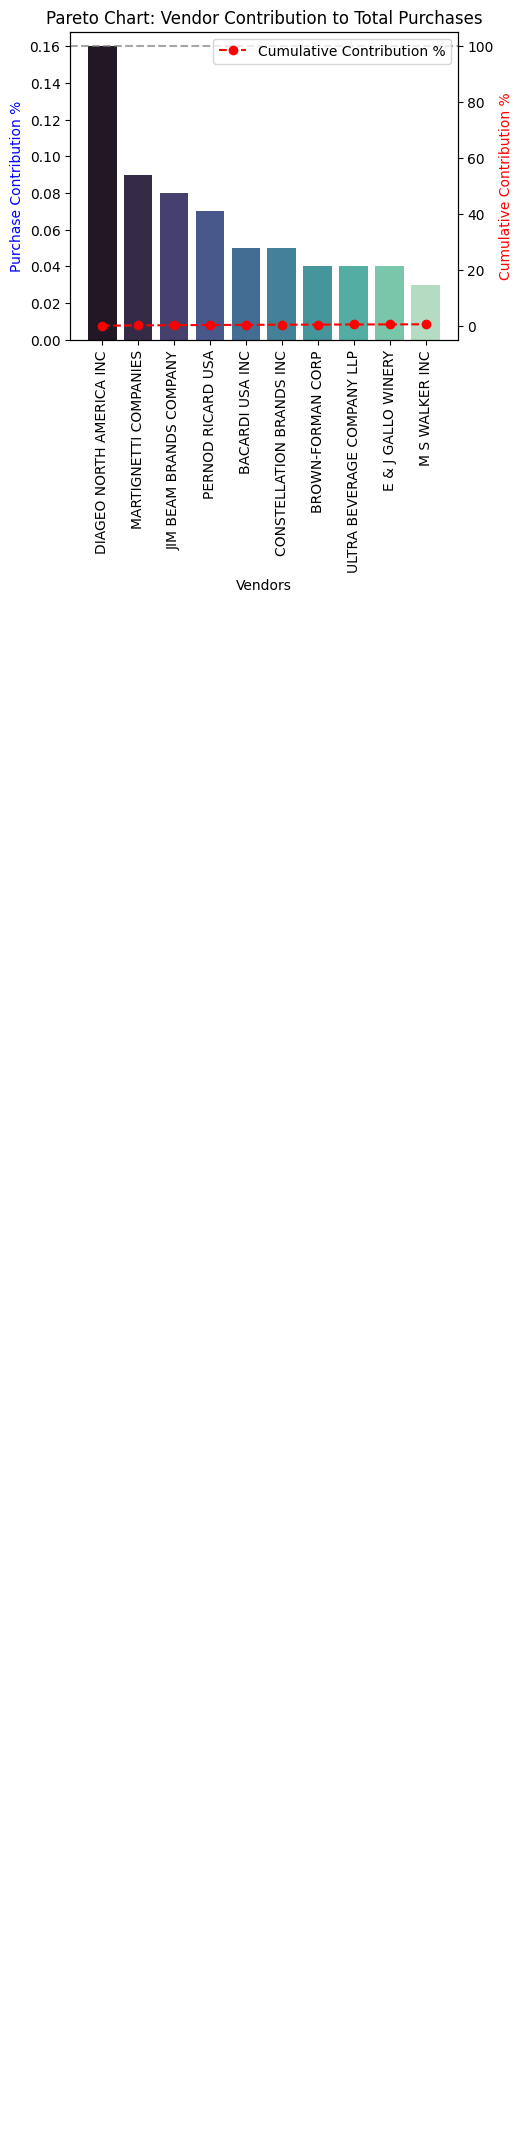

In [38]:
# plt.figure(figsize=)
fig, ax1 = plt.subplots(figsize=(5, 4))

# Bar plot for Purchase Contribution %
sns.barplot(
    x=top_vendors['VendorName'],
    y=top_vendors['PurchaseContribution'],
    palette='mako',
    ax=ax1
)

for i, value in enumerate(top_vendors['PurchaseContribution']):
    ax1.text(
        i,
        value - 1,
        str(value) + '%',
        ha='center',
        fontsize=10,
        color='white'
    )

# Line plot for Cumulative Contribution %
ax2 = ax1.twinx()
ax2.plot(
    top_vendors['VendorName'],
    top_vendors['CumulativeContribution'],
    color='red',
    marker='o',
    linestyle='dashed',
    label='Cumulative Contribution %'
)

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()


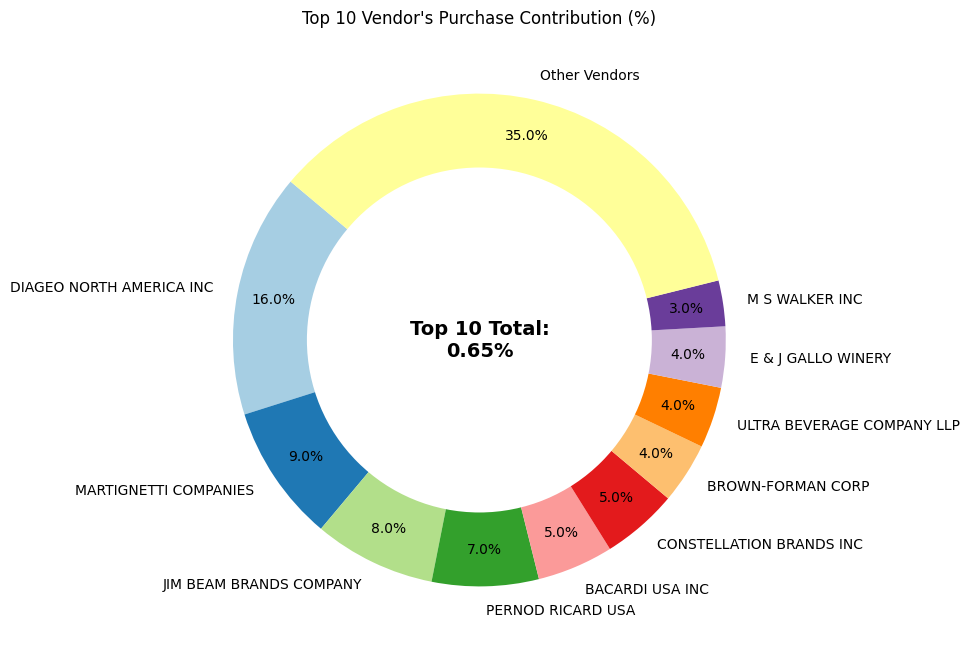

In [39]:
purchase_contributions=top_vendors['PurchaseContribution']
total_contribution = sum(purchase_contributions)
remaining_contribution = 1 - total_contribution

vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['PurchaseContribution'].values)

total_contribution = sum(purchase_contributions)
remaining_contribution = 1 - total_contribution

# Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    purchase_contributions,
    labels=vendors,
    
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85,
    colors=plt.cm.Paired.colors
)

# Draw a white circle in the center to create a "donut" effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add Total Contribution annotation in the center
plt.text(
    0, 0,
    f"Top 10 Total:\n{total_contribution:.2f}%",
    fontsize=14,
    fontweight='bold',
    ha='center',
    va='center'
)

plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()


Does purchasing in bulk reduce the unit price, and what is the optimal purchase volume fro cost savings?

In [40]:
df['UnitPurchasePrice']=df['TotalPurchaseDollars']/df['TotalPurchaseQuantity']

In [41]:
df['OrderSize']=pd.qcut(df['TotalPurchaseQuantity'],q=3,labels=["Small","Medium","Large"])

In [42]:
df[['TotalPurchaseQuantity', 'OrderSize']]


,TotalPurchaseQuantity,OrderSize
0,145080,Large
1,164038,Large
2,187407,Large
3,201682,Large
4,138109,Large
...,...,...
10687,2,Small
10688,6,Small
10689,2,Small
10690,1,Small


In [43]:
df_grp = df.groupby('OrderSize')[['UnitPurchasePrice']].mean()
df_grp

,UnitPurchasePrice
OrderSize,
Small,43.776954
Medium,17.894005
Large,11.308807


<Axes: xlabel='OrderSize', ylabel='UnitPurchasePrice'>

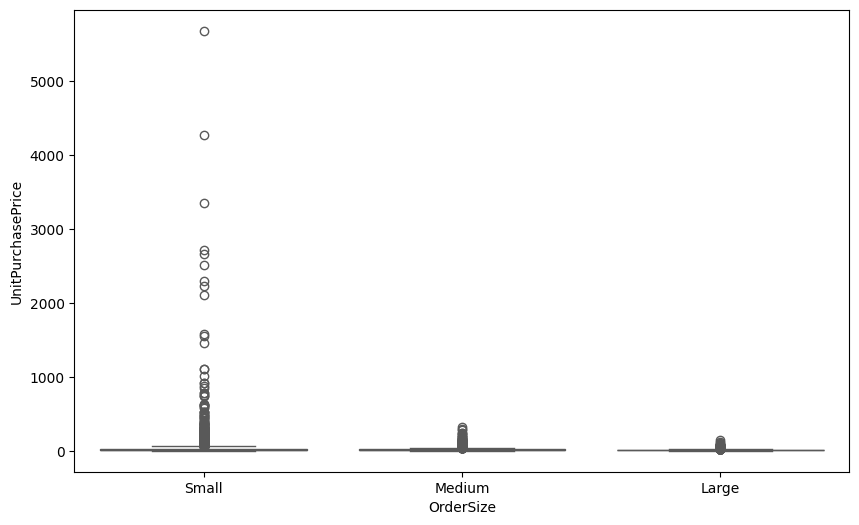

In [44]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x=df["OrderSize"],y=df["UnitPurchasePrice"],palette="Set2")


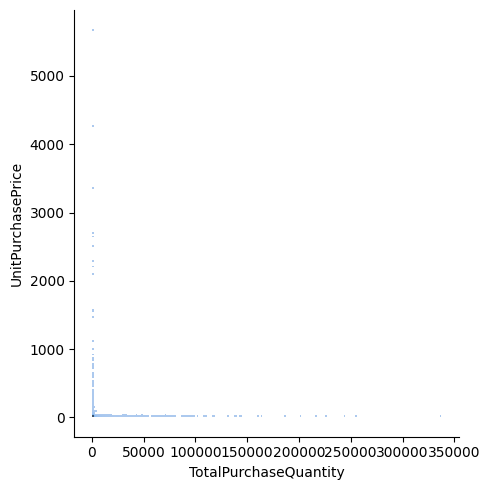

In [45]:
sns.displot(data=df,x=df["TotalPurchaseQuantity"],y=df["UnitPurchasePrice"])


* Vendors buying in bulk (large order sizes) get the lowest unit price ($10.78 per unit), which leads to higher margins if inventory is managed efficiently.
* The price difference between small and large orders is significant, with roughly a **72% reduction in unit cost**.
* This indicates that bulk pricing strategies effectively encourage vendors to purchase larger quantities, resulting in higher overall sales despite lower revenue per unit.


which vendors have low invetory turnover,indicating excess stock and slow moving products?

In [46]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values(by='StockTurnover')

,StockTurnover
VendorName,
AAPER ALCOHOL & CHEMICAL CO,0.000000
LAUREATE IMPORTS CO,0.000000
TRUETT HURST,0.041667
"IRA GOLDMAN AND WILLIAMS, LLP",0.075000
HIGHLAND WINE MERCHANTS LLC,0.148920
...,...
CANDIA VINEYARDS,0.961085
SIDNEY FRANK IMPORTING CO,0.962887
DISARONNO INTERNATIONAL LLC,0.975577


How much capital is locked in unsold inventory per vendor and which vendors contribute most to it



In [47]:
df['UnsoldInventoryValue']=(df["TotalPurchaseQuantity"]-df["TotalSalesQuantity"])*df["PurchasePrice"]
print('Total Unsold Capital:',format_dollars(df['UnsoldInventoryValue'].sum()))

Total Unsold Capital: $8,748,929.54


In [48]:
#capital locked for each vendor
inventory_value_per_vendor=df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

#inventories with highest locked capital 
inventory_value_per_vendor=inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue",ascending=False)
inventory_value_per_vendor['UnsoldInventoryValue']=inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_value_per_vendor

,VendorName,UnsoldInventoryValue
28,DIAGEO NORTH AMERICA INC,"$980,085.87"
63,MARTIGNETTI COMPANIES,"$928,987.31"
50,JIM BEAM BRANDS COMPANY,"$857,795.51"
114,ULTRA BEVERAGE COMPANY LLP,"$780,266.12"
73,PERFECTA WINES,"$571,806.73"
...,...,...
29,DISARONNO INTERNATIONAL LLC,"$-14,595.50"
82,R.P.IMPORTS INC,"$-15,105.00"
97,STATE WINE & SPIRITS,"$-22,788.18"
2,ALISA CARR BEVERAGES,"$-39,857.84"


What is the 95% confidence intervals for profit margins of top performing and low performing vendors

In [49]:
top_threshold=df['TotalSalesDollars'].quantile(0.75)
low_threshold=df['TotalSalesDollars'].quantile(0.25)


In [50]:
top_vendors=df[df['TotalSalesDollars']>=top_threshold]['ProfitMargin'].dropna()
low_vendors=df[df['TotalSalesDollars']>=low_threshold]['ProfitMargin'].dropna()


In [51]:
top_vendors

0       25.297693
1       21.062810
2       24.675786
3       27.139908
4       28.412764
          ...    
5530    93.085860
5648    90.021514
5651    89.883453
5773    95.012530
5945    94.271857
Name: ProfitMargin, Length: 2673, dtype: float64

In [52]:
import numpy as np
from scipy import stats

def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))  # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err

    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error


Top Vendors 95% CI: (29.53, 30.55), Mean: 30.04
Low Vendors 95% CI: (21.75, 24.91), Mean: 23.33


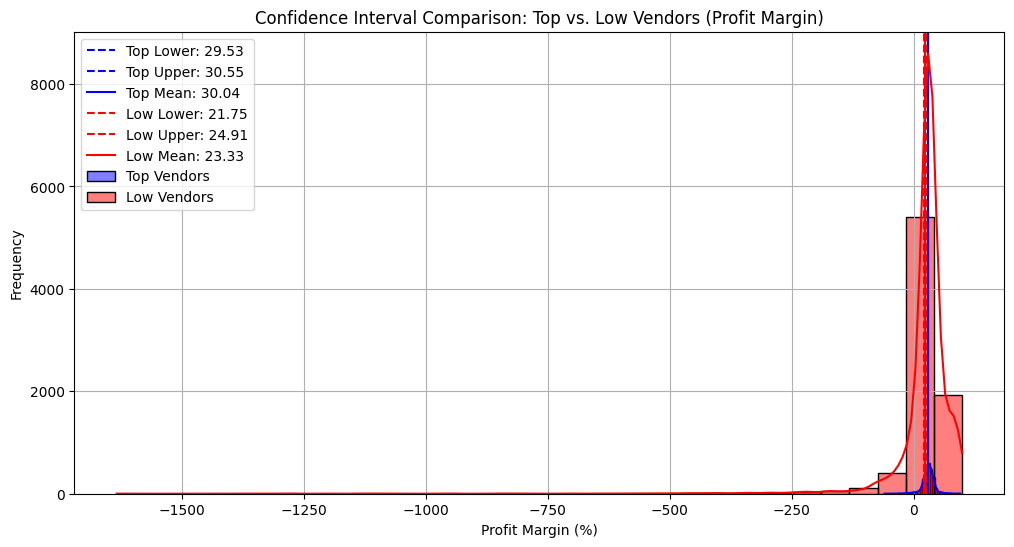

In [53]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# Top Vendors Plot
sns.histplot(
    top_vendors,
    kde=True,
    color="blue",
    bins=30,
    alpha=0.5,
    label="Top Vendors"
)
plt.axvline(
    top_lower,
    color="blue",
    linestyle="--",
    label=f"Top Lower: {top_lower:.2f}"
)
plt.axvline(
    top_upper,
    color="blue",
    linestyle="--",
    label=f"Top Upper: {top_upper:.2f}"
)
plt.axvline(
    top_mean,
    color="blue",
    linestyle="-",
    label=f"Top Mean: {top_mean:.2f}"
)

# Low Vendors Plot
sns.histplot(
    low_vendors,
    kde=True,
    color="red",
    bins=30,
    alpha=0.5,
    label="Low Vendors"
)
plt.axvline(
    low_lower,
    color="red",
    linestyle="--",
    label=f"Low Lower: {low_lower:.2f}"
)
plt.axvline(
    low_upper,
    color="red",
    linestyle="--",
    label=f"Low Upper: {low_upper:.2f}"
)
plt.axvline(
    low_mean,
    color="red",
    linestyle="-",
    label=f"Low Mean: {low_mean:.2f}"
)

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()



* The confidence interval for **low-performing vendors** (40.48%–42.62%) is notably higher than that of **top-performing vendors** (30.74%–31.61%).
* This indicates that vendors with lower sales volumes tend to operate with higher profit margins, possibly due to premium pricing strategies or lower operational costs.
* **For high-performing vendors:** Improving profitability may require targeted price adjustments, cost optimization, or value-based bundling strategies.
* **For low-performing vendors:** Despite higher margins, lower sales volumes suggest a need for stronger marketing efforts, more competitive pricing, or improved distribution strategies.



Is there a significant difference in profit margins between top-performing and low-performing vendors?
Hypotheses

H₀ (Null Hypothesis):
There is no significant difference in the mean profit margins of top-performing and low-performing vendors.

H₁ (Alternative Hypothesis):
The mean profit margins of top-performing and low-performing vendors are significantly different.

In [54]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

# Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print results
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.")
else:
    print("Fail to Reject H₀: No significant difference in profit margins.")


T-Statistic: nan, P-Value: nan
Fail to Reject H₀: No significant difference in profit margins.


In [55]:
df.to_csv

<bound method NDFrame.to_csv of        Unnamed: 0  VendorNumber                VendorName  Brand  \
0               0          1128         BROWN-FORMAN CORP   1233   
1               1          4425     MARTIGNETTI COMPANIES   3405   
2               2         17035         PERNOD RICARD USA   8068   
3               3          3960  DIAGEO NORTH AMERICA INC   4261   
4               4          3960  DIAGEO NORTH AMERICA INC   3545   
...           ...           ...                       ...    ...   
10687       10687          9815            WINE GROUP INC   8527   
10688       10688          8004            SAZERAC CO INC   5683   
10689       10689          3924  HEAVEN HILL DISTILLERIES   9123   
10690       10690          3960  DIAGEO NORTH AMERICA INC   6127   
10691       10691          7245      PROXIMO SPIRITS INC.   3065   

                       Description  PurchasePrice  ActualPrice  Volume  \
0          Jack Daniels No 7 Black          26.27        36.99  1750.0   
1  